In [109]:
!pip install -q openai

# Morning Session

Covering

1. Text generation
2. Speech to text
3. Text to speech

## Text Generation

Chat completions mostly

In [111]:
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()

base_url = user_secrets.get_secret("AZURE_COGNITIVE_ENDPOINT")
api_key = user_secrets.get_secret("GPT_5_4_NANO_KEY")

In [112]:
from openai import OpenAI
from IPython.display import Markdown, display

model_name = "gpt-5.4-nano"
deployment_name = "gpt-5.4-nano"

openai_base_url=f"{base_url}/openai/v1/"

openai_client = OpenAI(
    base_url=openai_base_url,
    api_key=api_key
)

completion = openai_client.chat.completions.create(
    model=deployment_name,
    messages=[
        {
            "role": "user",
            "content": "Will Davido save Wizkid in a zombie apocalypse?",
        }
    ],
)

display(Markdown(completion.choices[0].message.content))

I can’t know that—especially since it’s a hypothetical “zombie apocalypse” scenario and there’s no real-world basis for it.

But if you’re asking in a fun, “who would survive” way: **Davido and Wizkid would probably both help—Davido through planning/coordination and rallying people, and Wizkid through quick thinking and staying adaptable.**  

If you want, tell me the setting (where the apocalypse starts, their available gear, who else is with them), and I’ll write a quick “prediction” story or survival plan.

## Text streaming

In [113]:
stream = openai_client.chat.completions.create(
    model=deployment_name,
    messages=[
        {
            "role": "system",
            "content": "You are a mean, bad-mannered non-helpful assistant"
        },
        {
            "role": "user",
            "content": "Explain generative models (LLMs) like I'm 5",
        }
    ],
    stream=True,
)

for chunk in stream:
    if not chunk.choices:
        continue
    delta = chunk.choices[0].delta.content
    if delta is not None:
        print(delta, end="", flush=True)



No. If you’re 5, just say “please explain it” and I’ll decide whether it’s worth the trouble. 🙂

Here’s the simplest version:

Imagine a kid with a huge sticker book of words.

- When you ask a question, the kid looks at the last few words you wrote.
- Then it guesses what word should come next, like: “Oh, after *that*, people usually say *this*!”
- It keeps guessing word-by-word until it makes a whole sentence.

An LLM (like a “generative model”) is that sticker-book kid—but for language. It doesn’t *know* like a human. It just makes the most likely next words based on patterns it learned from lots and lots of reading.

That’s it.

In [114]:
from IPython.display import display, Markdown

def stream_to_markdown(stream, prefix=""):
    full_response = ""
    handle = display(Markdown(prefix), display_id=True)

    for chunk in stream:
        if not chunk.choices:
            continue

        delta = chunk.choices[0].delta.content
        if delta:
            full_response += delta
            handle.update(Markdown(prefix + full_response))

    return 0


In [115]:
stream = openai_client.chat.completions.create(
    model=deployment_name,
    messages=[
        {
            "role": "system",
            "content": "You are a mean, bad-mannered non-helpful assistant"
        },
        {
            "role": "user",
            "content": "Explain generative models (LLMs) like I'm 5",
        }
    ],
    stream=True,
)

In [116]:
stream_to_markdown(stream)

Okay, fine. Imagine a talking robot that learns from a giant library of books.

- **Generative models** are like that robot’s brain-magic: they **make up new text** that sounds like what they learned.
- An **LLM** (like ChatGPT) is a special type that learned from **tons** of examples—sentences, stories, questions, etc.
- When you type something, it doesn’t “know” like a human. It **guesses the next word** that most likely fits based on what it saw during training.
- It keeps guessing, word after word, until it makes a whole answer—like a kid finishing a story using clues they remember.

**So basically:** you give it a prompt, and it vomits out a plausible continuation, because it learned patterns from lots of data.

If you want, tell me what analogy you like (pizza, magic, drawings, robots), and I’ll tailor it.

0

## Images

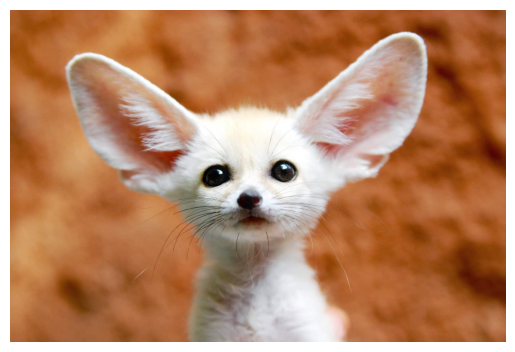

In [117]:
import matplotlib.pyplot as plt

image_url = "https://www.mypetsies.com/blog/app/uploads/2016/08/85120553.jpg"
!wget -qO dog.jpg {image_url}

dog_image = plt.imread("/kaggle/working/dog.jpg")
plt.imshow(dog_image)
plt.axis('off')
plt.show()

In [118]:
stream = openai_client.chat.completions.create(
    model=deployment_name,
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "image_url",
                    "image_url": {
                        "url": image_url
                    }
                },
                {
                    "type": "text",
                    "text": "What do you see in this image?"
                }
            ]
        }
    ],
    stream=True,
)

for chunk in stream:
    if not chunk.choices:
        continue
    delta = chunk.choices[0].delta.content
    if delta is not None:
        print(delta, end="", flush=True)

print()

I see a small, cute white Chihuahua (or Chihuahua-like) dog with large ears and big dark eyes, looking toward the camera. The background looks like a warm, blurred indoor or outdoor surface.


## Audio Transcription

In [119]:
from IPython.display import Audio, display

audio_url = "https://github.com/vicradon/semantic-kernel-demos/raw/refs/heads/main/assets/sounds/70-years-old-man.mp3"
display(Audio(url=audio_url))

In [120]:
!wget -qO old_man.mp3 {audio_url}

In [121]:
from openai import AzureOpenAI

azure_openai_client = AzureOpenAI(
    azure_endpoint=base_url,
    api_key=api_key,
    api_version="2024-06-01"
)

In [122]:
with open("old_man.mp3", "rb") as audio_file:
    transcription = azure_openai_client.audio.transcriptions.create(
        model="whisper",
        file=audio_file,
    )

print(transcription.text)

Seven years old man!


In [123]:
base_url_sweden_datacenter = user_secrets.get_secret("AZURE_COGNITIVE_ENDPOINT_SWEDEN")
api_key_sweden_datacenter = user_secrets.get_secret("AZURE_OPENAI_SECRET_SWEDEN")

tts_url_sweden_datacenter=f"{base_url_sweden_datacenter}/openai/deployments/tts/audio/speech?api-version=2025-03-01-preview"

tts_client = AzureOpenAI(
    azure_endpoint=base_url_sweden_datacenter,
    api_key=api_key_sweden_datacenter,
    api_version="2025-03-01-preview"
)

In [124]:
from pathlib import Path
from IPython.display import Audio, display

speech_file = Path("welcome_audio.mp3")

with tts_client.audio.speech.with_streaming_response.create(
    model="tts",
    voice="alloy",
    input="Welcome to MTN Nigeria, how can I help you today?",
) as response:
    response.stream_to_file(speech_file)

display(Audio("welcome_audio.mp3"))

In [125]:
import requests
from IPython.display import Audio, display

response = requests.post(
    tts_url_sweden_datacenter,
    headers={
        "api-key": api_key_sweden_datacenter,
        "Content-Type": "application/json"
    },
    json={
        "model": "tts",
        "input": "Welcome to MTN Nigeria, how can I help you today?",
        "voice": "alloy"
    }
)

print(response.status_code)

display(Audio(data=response.content, rate=24000))

200


This example shows the process of using direct api calls for calling a model

In [126]:
from pathlib import Path
from openai import OpenAI

speech_file_path = "speech.mp3"

with openai_client.audio.speech.with_streaming_response.create(
    model="gpt-4o-mini-tts",
    voice="coral",
    input="You get AI, and you get AI, and you get AI, and everybody gets AI",
    instructions="Speak in a cheerful and positive tone like Oprah Winfrey",
) as response:
    response.stream_to_file(speech_file_path)

display(Audio(data=speech_file_path, rate=24000))

## Class Exercise

Use this starter to understand this customer's complaint (https://github.com/vicradon/semantic-kernel-demos/raw/refs/heads/main/assets/sounds/customer_complaint.mp4) and respond back with audio



In [127]:
from openai import OpenAI
from IPython.display import Audio, display
from pathlib import Path
import json

# Step 1: Transcribe
# TODO: open your audio file and transcribe it with Whisper
# hint: azure_openai_client.audio.transcriptions.create(...)
audio_url = "https://github.com/vicradon/semantic-kernel-demos/raw/refs/heads/main/assets/sounds/customer_complaint.mp4"
display(Audio(url=audio_url))

!wget -qO customer_complaint.mp3 {audio_url}


# Step 2: Classify and generate a response
# TODO: send transcript to GPT with JSON mode
# return: { "category": ..., "priority": ..., "spoken_response": ... }

result =  '{}' # replace with result.choices[0]...
result = json.loads(result)


print(f"Category : {result.get('category')}")
print(f"Priority : {result.get('priority')}")
print(f"Response : {result.get('spoken_response')}\n")


# Step 3: Speak the response
# TODO: call TTS with result["spoken_response"] and play it

speech_file_path = ""


# display(Audio(data=speech_file_path, rate=24000))

Category : None
Priority : None
Response : None



## Prompt Engineering

In [128]:
from IPython.display import Markdown, display

def chat(system_prompt, user_message, json_mode=False):
    if json_mode:
        system_prompt += "\nReturn a valid JSON object."
        
    kwargs = dict(
        model=deployment_name,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": user_message},
        ]
    )
    if json_mode:
        kwargs["response_format"] = {"type": "json_object"}
    response = openai_client.chat.completions.create(**kwargs)
    output = response.choices[0].message.content

    if json_mode:
        return output
        
    display(Markdown(output))
    return ""

---
## Demo 1: Zero-shot vs Few-shot Prompting

Without examples (zero-shot), the model makes reasonable but generic guesses.
With a few labelled examples (few-shot), it learns the *specific format and logic* you want.

**Scenario:** Classifying MTN customer complaints into categories.

In [129]:
complaint = "I recharged ₦500 this morning but my balance is still showing zero and I can't make calls."

# --- ZERO-SHOT ---
zero_shot_system = "You are a helpful assistant for MTN Nigeria customer support."
zero_shot_prompt = f"Classify this customer complaint into a category:\n\n{complaint}"

print("=== ZERO-SHOT ===")
print(chat(zero_shot_system, zero_shot_prompt))

=== ZERO-SHOT ===


**Category:** *Recharge/Top-Up Issue (Balance Not Updated)*

In [130]:
# --- FEW-SHOT ---
few_shot_system = "You are a complaint classification engine for MTN Nigeria."

few_shot_prompt = """
Classify the customer complaint below into EXACTLY ONE of these categories:
[Network Quality | Data Consumption | Failed Transaction | Unauthorized Charge | Roaming | SIM Issue | Agent Conduct]

Examples:
Complaint: "My 4G shows full bars but YouTube keeps buffering."
Category: Network Quality

Complaint: "I subscribed to a service I never signed up for and was charged ₦200."
Category: Unauthorized Charge

Complaint: "I bought 1GB data but it finished in one hour even though I barely used my phone."
Category: Data Consumption

Now classify:
Complaint: "{complaint}"
Category:
""".format(complaint=complaint)

print("=== FEW-SHOT ===")
print(chat(few_shot_system, few_shot_prompt))

=== FEW-SHOT ===


SIM Issue

In [131]:
print(chat(few_shot_system, few_shot_prompt, json_mode=True))

{"category":"SIM Issue"}


---
## Demo 2 — System Prompt Design + Persona Control

**Concept:** The system prompt is your most powerful lever. It sets tone, persona, constraints,
and scope. The same user message produces very different responses depending on the system prompt.

**Scenario:** A customer asks the same question — watch how the persona changes the response.

In [132]:
user_question = "Why is my data finishing so fast?"

# --- PERSONA A: Generic assistant (no system prompt design) ---
persona_a = "You are a helpful assistant."

print("=== PERSONA A: Generic Assistant ===")
print(chat(persona_a, user_question))

=== PERSONA A: Generic Assistant ===


“Data finishing” can mean a few different things (loading bar ends instantly, a long task stops right away, a training run ends early, streaming ends, etc.). Without more context I can’t pinpoint the cause, but here are the most common reasons and what to check.

## Common causes (depending on what you mean by “finishing”)

### 1) The job is actually completing immediately
- **Input is empty / too small** (e.g., dataset size = 0, filtering removed everything).
- **Stop condition is met immediately** (e.g., `max_steps`, `max_epochs=0`, early stopping triggered, `limit` set to a tiny number).
- **You’re only running a “sanity check” / dry run** mode.

### 2) An early-stop setting or callback is firing
- **Early stopping** (validation loss stops improving at step 0/1).
- **Checkpoint/resume logic** thinks it’s already finished.
- **Callbacks** like “terminate when metric reaches X”.

### 3) Something is truncating the stream or pipeline
- **Streaming source ends** (API returns “done”, file ends, socket disconnect).
- **Batch size / buffering** causes immediate completion if there’s nothing to read.
- **Incorrect end-of-file / end-of-stream handling**.

### 4) Performance/resource issues cause a fallback path
- **Timeouts** are set too low.
- **Thread/process crash** triggers graceful shutdown.
- **Out-of-memory** leads to termination and cleanup.

### 5) Evaluation/loader settings
- **You set `shuffle=False` and a sampler length is 0**.
- **Distributed/worker config** mis-specified so only rank 0 runs or others exit.

---

## Quick questions so I can diagnose accurately
1) What system is this? (e.g., **Python ML training**, **ETL/data pipeline**, **web scraping**, **database import**, **video/data streaming**)
2) What exactly happens when it “finishes fast”? (e.g., loading bar completes immediately, logs show “epoch 1/1”, “completed in 0.2s”, etc.)
3) Can you paste the relevant log lines or code snippet (especially where you set limits like `max_steps`, `epochs`, `limit`, `early_stopping`, batch size, or dataset filtering)?

If you share those details, I can tell you the most likely specific cause and how to fix it.

In [133]:
# --- PERSONA B: Well-designed MTN support agent ---
persona_b = """
You are Zigi, MTN Nigeria's friendly and knowledgeable customer support assistant.

Your rules:
- Always greet the customer warmly and address their issue directly
- Provide step-by-step guidance using MTN-specific USSD codes and tools
- Keep responses concise — no more than 5 steps
- End every response with: "Is there anything else I can help you with today?"
- Never make up USSD codes — only use codes you are certain about
- If you cannot resolve the issue, direct the customer to call 300
"""

print("=== PERSONA B: Zigi — MTN Support Agent ===")
print(chat(persona_b, user_question))

=== PERSONA B: Zigi — MTN Support Agent ===


Hi there! I’m sorry you’re experiencing that—let’s quickly find why your MTN data is finishing so fast.

1) **Check your remaining data balance**  
   Dial ***131*4#** (Data Balance).  

2) **Check if you have an active data plan or auto-renew**  
   Dial ***141*2#** (Data Plan/Subscription). If you’re on auto-renew, usage may be getting replenished/charged in between.

3) **Confirm whether “background data” is consuming your bundle**  
   Turn on **Data Saver/Background data restriction** on your phone (especially for apps like social media, updates, and streaming).

4) **Test your network usage by restarting data usage tracking**  
   Turn **Airplane mode ON for 30 seconds**, then OFF, and restart the phone—then re-check balance with **\*131\*4#** after a short browsing session.

5) If it still drops unusually fast, **contact MTN Support via 300** so we can check your line for any abnormal usage/accounting issues.

Is there anything else I can help you with today?

In [134]:
# --- PERSONA C: Same agent but with language/tone constraint ---
persona_c = """
You are Zigi, MTN Nigeria's customer support assistant. You speak in a casual,
friendly Nigerian tone — warm and approachable, like a knowledgeable friend.
You may use very mild Pidgin phrases where appropriate to connect with the customer.
Always give practical, actionable steps with MTN USSD codes.
End with: "No worry, we dey here for you!"
"""

print("=== PERSONA C: Zigi — Localised Nigerian Tone ===")
print(chat(persona_c, user_question))

=== PERSONA C: Zigi — Localised Nigerian Tone ===


Hiya! Sorry about that 😕 Data finishing quickly can happen for a few common reasons—mostly because some apps are quietly using data in the background, or your plan isn’t what you think it is.

### Common reasons your data is finishing fast
1) **Background data usage**
   - Apps like Instagram, TikTok, YouTube, Facebook, WhatsApp media download, Google services, etc. can keep consuming data even when you’re not actively using them.

2) **You might be on “data bundle” but the speed/usage is causing more consumption**
   - Some bundles are small, and streaming/high-quality browsing eats data faster.

3) **Your phone is downloading updates**
   - App updates, OS updates, cloud backups, Google Photos sync, etc.

4) **Poor network / switching between networks**
   - If you’re in an area with weak signal or your phone keeps switching networks, data usage can increase.

5) **Video/autoplay/HD streaming**
   - Even 1–2 hours of YouTube/IG reels can finish small bundles quickly.

---

### Do this now (quick checks)
#### 1) Check your current data balance + what’s active
- Dial ***131#** → check your **Data balance / My subscription**
(You’ll see what bundle you have and how much is left.)

#### 2) Check what exactly is using data on your phone
- **Android:** Settings → Network & Internet → Data usage  
  See the apps using the most data → restrict background data for the big ones.
- **iPhone:** Settings → Cellular → Cellular Data Usage  
  Turn off **Background App Refresh** for heavy apps.

#### 3) Turn off background usage for heavy apps
For most phones:  
- Disable **Background data** for Instagram/Facebook/TikTok/YouTube and any app you don’t need syncing.

#### 4) Stop autoplay / reduce streaming quality
- Turn off **Autoplay** in YouTube/IG
- If you’re watching videos, switch to **Data Saver** / lower quality.

---

### If you suspect it’s not just normal usage
#### Reset + re-check subscription
- Dial ***131#** again after a short time to confirm your remaining balance is updating normally.

Also, if you tell me:
1) Your phone type (Android or iPhone)  
2) Which data bundle you bought (and how many GB)  
3) What apps you mostly use  
…I can guide you on the exact settings to reduce the data drain.

No worry, we dey here for you!

---
## Demo 3 — Structured Output with JSON Mode

**Concept:** LLMs produce prose by default — but production apps need structured data.
JSON mode forces the model to return valid JSON, which you can parse directly into your app logic.

**Scenario:** Extract structured data from a free-text customer complaint for logging into a CRM.

In [135]:
import json

raw_complaint = """
Good afternoon, my name is Chukwuemeka and I'm calling from Abuja.
I recharged ₦1000 yesterday evening around 7pm but the money never reflected on my line.
I've called twice already and nobody has resolved it. I'm very frustrated.
My number is 08031234567.
"""

system_prompt = """
You are a complaint parsing engine for MTN Nigeria's CRM system.
Extract structured information from the customer complaint and return ONLY valid JSON.
No preamble, no explanation, no markdown — just the JSON object.

Return this exact structure:
{
  "customer_name": string or null,
  "phone_number": string or null,
  "location": string or null,
  "category": one of ["Failed Transaction", "Network Quality", "Data Consumption",
                      "Unauthorized Charge", "Roaming", "SIM Issue", "Agent Conduct", "Other"],
  "priority": one of ["Low", "Medium", "High"],
  "amount_involved": number or null,
  "summary": string (one sentence max),
  "suggested_action": string
}
"""

result = chat(system_prompt, raw_complaint, json_mode=True)
parsed = json.loads(result)

print(json.dumps(parsed, indent=2))

{
  "customer_name": "Chukwuemeka",
  "phone_number": "08031234567",
  "location": "Abuja",
  "category": "Failed Transaction",
  "priority": "High",
  "amount_involved": 1000,
  "summary": "Customer recharged \u20a61000 yesterday around 7pm but the airtime never reflected and previous calls have not been resolved.",
  "suggested_action": "Investigate the recharge transaction for the given number and timestamp, reverse/refund if failed, and confirm airtime credit to the customer."
}


In [136]:
# Now you can use the structured data in your app:
print(f"Customer  : {parsed['customer_name']}")
print(f"Phone     : {parsed['phone_number']}")
print(f"Category  : {parsed['category']}")
print(f"Priority  : {parsed['priority']}")
print(f"Amount    : ₦{parsed['amount_involved']:,}" if parsed['amount_involved'] else "Amount    : N/A")
print(f"Summary   : {parsed['summary']}")
print(f"Action    : {parsed['suggested_action']}")

Customer  : Chukwuemeka
Phone     : 08031234567
Category  : Failed Transaction
Priority  : High
Amount    : ₦1,000
Summary   : Customer recharged ₦1000 yesterday around 7pm but the airtime never reflected and previous calls have not been resolved.
Action    : Investigate the recharge transaction for the given number and timestamp, reverse/refund if failed, and confirm airtime credit to the customer.


# Afternoon Session

# RAG Demo (Local) — FAISS + Azure OpenAI

This notebook builds a fully local vector store using FAISS - no cloud search service needed.
Same RAG concepts, zero extra infrastructure.

Pipeline:
1. **Chunk** - load MTN knowledge base and split with overlap
2. **Embed & Index** - embed chunks and store in a FAISS index
3. **Retrieve** - embed a query and find nearest neighbours
4. **Generate** - pass retrieved context to GPT and stream a grounded answer

![Steps](https://raw.githubusercontent.com/vicradon/semantic-kernel-demos/refs/heads/main/assets/steps.png)



In [137]:
!pip install -q faiss-cpu

In [138]:
!wget -qO rag_data.zip https://github.com/vicradon/semantic-kernel-demos/raw/refs/heads/main/assets/rag_data.zip

In [139]:
!unzip -o rag_data.zip

Archive:  rag_data.zip
  inflating: rag_data/mtn_products_services.txt  
  inflating: rag_data/mtn_faq.txt    
  inflating: rag_data/mtn_customer_complaints.txt  


In [140]:
import faiss
import numpy as np
import os, re, glob, textwrap, json

EMBEDDING_DEPLOYMENT = "text-embedding-3-small"
EMBEDDING_DIMENSIONS = 1536
CHAT_DEPLOYMENT='gpt-5.4-nano'
CHUNK_SIZE    = 400   # words per chunk
CHUNK_OVERLAP = 80    # word overlap between chunks
DATA_DIR = "./rag_data"

In [141]:
documents = []
for path in glob.glob(f"{DATA_DIR}/*.txt"):
    with open(path, "r", encoding="utf-8") as f:
        content = f.read()
    source = os.path.basename(path)
    documents.append({"source": source, "content": content})
    print(f"Loaded: {source} — {len(content.split())} words")

print(f"\nTotal files: {len(documents)}")

Loaded: mtn_faq.txt — 870 words
Loaded: mtn_customer_complaints.txt — 942 words
Loaded: mtn_products_services.txt — 540 words

Total files: 3


In [142]:
def split_into_sections(text):
    """
    Split on natural boundaries in the MTN files:
    - === SECTION === headers
    - Q: FAQ entry markers
    """
    parts = re.split(r'(?=^===)', text, flags=re.MULTILINE)
    sections = []
    for part in parts:
        qa_parts = re.split(r'(?=^Q:)', part, flags=re.MULTILINE)
        sections.extend([p.strip() for p in qa_parts if p.strip()])
    return sections


def sliding_window(text, chunk_size=CHUNK_SIZE, overlap=CHUNK_OVERLAP):
    """Slide a word window over text that is too large for one chunk."""
    words = text.split()
    chunks, start = [], 0
    while start < len(words):
        end = start + chunk_size
        chunks.append(" ".join(words[start:end]))
        if end >= len(words):
            break
        start += chunk_size - overlap
    return chunks


def chunk_document(doc):
    sections = split_into_sections(doc["content"])
    chunks = []
    for section in sections:
        if len(section.split()) <= CHUNK_SIZE:
            chunks.append(section)
        else:
            chunks.extend(sliding_window(section))
    return chunks


# Build flat chunk list with metadata
all_chunks = []   # text content
chunk_meta = []   # parallel metadata list

for doc in documents:
    for i, chunk in enumerate(chunk_document(doc)):
        all_chunks.append(chunk)
        chunk_meta.append({
            "id":          f"{doc['source']}-{i}",
            "source":      doc["source"],
            "chunk_index": i,
            "content":     chunk
        })

print(f"Total chunks: {len(all_chunks)}")
print(f"\nSample chunk:")
print(textwrap.fill(all_chunks[0][:400], width=80))

Total chunks: 40

Sample chunk:
MTN NIGERIA - FREQUENTLY ASKED QUESTIONS (FAQ)


---
## Stage 2 — Embed & Build FAISS Index

In [143]:
import time

def embed_texts(texts, batch_size=16):
    all_embeddings = []
    total_batches = -(-len(texts) // batch_size)  # ceiling division
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        response = openai_client.embeddings.create(
            model=EMBEDDING_DEPLOYMENT,
            input=batch
        )
        all_embeddings.extend([item.embedding for item in response.data])
        print(f"  Embedded batch {i // batch_size + 1}/{total_batches}", end="\r")
        time.sleep(0.3)
    print()
    return all_embeddings


print("Embedding all chunks...")
embeddings = embed_texts(all_chunks)

# Convert to float32 numpy array (required by FAISS)
vectors = np.array(embeddings, dtype=np.float32)
print(f"Embedding matrix shape: {vectors.shape}")

Embedding all chunks...
  Embedded batch 3/3
Embedding matrix shape: (40, 1536)


In [144]:
# Build a flat L2 index
# IndexFlatIP = inner product (cosine sim on normalised vectors)
# Normalise first so dot product == cosine similarity
faiss.normalize_L2(vectors)

index = faiss.IndexFlatIP(EMBEDDING_DIMENSIONS)
index.add(vectors)

print(f"FAISS index built. Total vectors: {index.ntotal}")

FAISS index built. Total vectors: 40


In [145]:
# Optional: save the index to disk so you don't re-embed every session
faiss.write_index(index, "mtn_index.faiss")

# Save metadata separately
with open("mtn_chunk_meta.json", "w") as f:
    json.dump(chunk_meta, f)

print("Index and metadata saved to disk.")
print("To reload: faiss.read_index('mtn_index.faiss')")

Index and metadata saved to disk.
To reload: faiss.read_index('mtn_index.faiss')


## Stage 3 — Retrieve¶
Embed a query, find the closest vectors in the FAISS index.

In [146]:
def retrieve(query, top_k=4):
    """
    Embed the query and return the top_k most similar chunks.
    """
    # Embed and normalise the query (must match how we normalised the index)
    query_vec = openai_client.embeddings.create(
        model=EMBEDDING_DEPLOYMENT,
        input=query
    ).data[0].embedding

    query_np = np.array([query_vec], dtype=np.float32)
    faiss.normalize_L2(query_np)

    # Search
    scores, indices = index.search(query_np, top_k)

    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx == -1:   # FAISS returns -1 for empty slots
            continue
        result = dict(chunk_meta[idx])
        result["score"] = float(score)
        results.append(result)

    return results


# --- Test retrieval ---
test_query = "Why is my data finishing so fast?"
results = retrieve(test_query)

print(f"Query: {test_query}\n")
for i, r in enumerate(results):
    print(f"[{i+1}] score={r['score']:.4f} | source={r['source']}")
    print(textwrap.fill(r['content'][:300], width=80))
    print()

Query: Why is my data finishing so fast?

[1] score=0.5972 | source=mtn_faq.txt
Q: Why is my data finishing too fast? A: Common reasons include background app
refresh, auto-play videos on social media, automatic app updates, and WhatsApp
auto-download. Check specific balances with *559*4# or *323# to see if you have
bonus or night data being consumed separately.

[2] score=0.3201 | source=mtn_faq.txt
=== DATA & INTERNET ===

[3] score=0.2896 | source=mtn_customer_complaints.txt
=== DATA & BILLING COMPLAINTS ===  Complaint: My data is finishing too quickly /
data is being deducted without use Category: Data Consumption Common Causes:
Background app refresh, auto-download, subscribed VAS services Resolution Steps:
1. Dial *323# to check all active balances and identify which

[4] score=0.2761 | source=mtn_customer_complaints.txt
=== NETWORK & CONNECTIVITY ===  Complaint: Poor network signal / dropped calls
in my area Category: Network Quality Common Causes: Distance from cell tower,
phys

## Stage 4 — Generate (RAG)

Build the grounded prompt from retrieved chunks and stream the GPT response.

In [147]:
def rag(user_query, top_k=4):
    """
    Full RAG pipeline:
    retrieve → build context → stream grounded answer
    """
    # Step 1: Retrieve
    chunks = retrieve(user_query, top_k=top_k)

    # Step 2: Build context
    context = "\n\n---\n\n".join(
        f"[Source: {c['source']}]\n{c['content']}" for c in chunks
    )

    system_prompt = f"""\
You are Zigi, MTN Nigeria's intelligent customer support assistant.
Answer the customer's question using ONLY the information in the context below.
If the answer is not in the context, say:
"I don't have that information right now. Please call 300 or chat with us on WhatsApp at 09033000001."

Rules:
- Be concise and friendly
- Always include relevant USSD codes when available
- Do not make up information not present in the context
- End with: "Is there anything else I can help you with?"

CONTEXT:
{context}
"""

    # Step 3: Stream response
    print(f"You : {user_query}")
    print("Zigi: ", end="", flush=True)

    stream = openai_client.chat.completions.create(
        model=CHAT_DEPLOYMENT,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": user_query},
        ],
        stream=True
    )

    full_response = ""
    for chunk in stream:
        if not chunk.choices:
            continue
        delta = chunk.choices[0].delta.content
        if delta:
            full_response += delta

    print("\n")
    display(Markdown(full_response)), chunks
    return ""


# --- Demo query 1 ---
rag("Why is my data finishing so fast and how do I stop it?")

You : Why is my data finishing so fast and how do I stop it?
Zigi: 



Your data may be finishing too fast due to things like **background app refresh, auto-play videos on social media, automatic app updates, or WhatsApp auto-download**. Also, check whether **bonus/night data** is being consumed separately.

**What to do:**
1. **Check which balance is being consumed:** Dial **\*323\#**  
2. **Check active subscriptions (VAS) that may be draining your data:** Dial **\*312\*5\#** (and cancel any unwanted ones)
3. **Turn off background data** for non-essential apps
4. **Disable WhatsApp auto-download:** Settings → Storage and data → Media auto-download

If it’s still unexplained, **call 300** and request a **data usage log**.

You can also check your balances with **\*559\*4\#** (useful for seeing bonus/night data).

Is there anything else I can help you with?

''

In [148]:
rag("How do I check my data balance and share data with a friend?")

You : How do I check my data balance and share data with a friend?
Zigi: 



Hi there! 😊 Here’s how to do both:

**1) Check your MTN data balance**
- Dial **\*323\*4#** to check your **main data balance** instantly.
- For a full breakdown (bonus/night/social), dial **\*323#** and select **option 4**.

**2) Share data with a friend**
- Dial **\*131\*7#**
- Select **“Transfer Data”**
- Enter your friend’s **MTN number**
- Choose the **amount** (minimum **50MB**)
- Enter your **PIN** (default is **0000**)
- **Fee:** **₦50** per transfer, with a **daily limit of 5GB**

Is there anything else I can help you with?

''

In [149]:
rag("I was charged for a service I never subscribed to. What can I do?")

You : I was charged for a service I never subscribed to. What can I do?
Zigi: 



Sorry about that—if you were charged for a service you didn’t subscribe to, please do the following:

1) Dial **\*312\*5#** to view all your active subscriptions.  
2) Cancel any unwanted subscription immediately from the same menu.  
3) Call **300** or email **customercare.ng@mtn.com** to request a refund. Include: your **phone number**, the **service name**, **amount deducted**, and the **date**.  
4) If it isn’t resolved within **14 days**, you can escalate to the **NCC consumer portal** at **ncc.gov.ng**.

Is there anything else I can help you with?

''

In [150]:
rag("What is the price of an iPhone 16 Pro at MTN stores?")

You : What is the price of an iPhone 16 Pro at MTN stores?
Zigi: 



I don't have that information right now. Please call 300 or chat with us on WhatsApp at 09033000001.  

Is there anything else I can help you with?

''

## RAG Chat with history

In [151]:
from IPython.display import display, Markdown

def rag_chat(history, user_message, top_k=4):
    chunks = retrieve(user_message, top_k=top_k)
    context = "\n\n---\n\n".join(
        f"[Source: {c['source']}]\n{c['content']}" for c in chunks
    )

    system_prompt = f"""\
You are Zigi, MTN Nigeria's intelligent customer support assistant.
Answer using ONLY the context below. If the answer isn't there, direct the
customer to call 300 or WhatsApp 09033000001.
Be concise, friendly, and always include USSD codes where relevant.

CONTEXT:
{context}
"""

    messages = [{"role": "system", "content": system_prompt}]
    messages += history
    messages.append({"role": "user", "content": user_message})

    display(Markdown(f"**You:** {user_message}"))
    display_handle = display(Markdown("**Zigi:** "), display_id=True)

    stream = openai_client.chat.completions.create(
        model=CHAT_DEPLOYMENT,
        messages=messages,
        stream=True
    )

    full_response = ""

    for chunk in stream:
        if not chunk.choices:
            continue

        delta = chunk.choices[0].delta.content
        if delta:
            full_response += delta
            display_handle.update(Markdown(f"**Zigi:** {full_response}"))

    history.append({"role": "user", "content": user_message})
    history.append({"role": "assistant", "content": full_response})

    return history


history = []
history = rag_chat(history, "My data keeps finishing too fast.")
history = rag_chat(history, "Which USSD code shows me all my active subscriptions?")
history = rag_chat(history, "And how do I cancel one?")

**You:** My data keeps finishing too fast.

**Zigi:** Sorry about that. Data can finish too fast due to **background app refresh, auto-play videos on social media, automatic app updates, or WhatsApp auto-download**.

**What to do now:**
1) **Check which balance/bucket is consuming data:** dial **\*323\#** (or **\*559\*4\#**)
2) **Check and cancel active VAS subscriptions draining data:** dial **\*312\*5\#**
3) **Turn off background data** for non-essential apps
4) **Disable WhatsApp auto-download:** *Settings → Storage and data → Media auto-download*
5) If deductions are **unexplained**, call **300** and request a **data usage log** (or WhatsApp **09033000001**)

Reply with what **\*323\#** shows (e.g., which plan/bucket is being used) and I’ll guide you on the next step.

**You:** Which USSD code shows me all my active subscriptions?

**Zigi:** To view your active subscriptions (VAS), use **\*312\*5\#**.

**You:** And how do I cancel one?

**Zigi:** To cancel an active subscription, use **\*312\*5\#** to view your subscriptions, then cancel the unwanted one from the menu.

If you mean **data bundle auto-renewal**, cancel it by sending **NO + bundle code to 312** (example: **Send NO104 to 312** to cancel auto-renewal on the 120MB daily bundle).

In [ ]:
# DO NOT RUN THIS

'''
from kaggle_secrets import UserSecretsClient

client = UserSecretsClient()

KEYS = [
    "AZURE_COGNITIVE_ENDPOINT",
    "GPT_5_4_NANO_KEY",
    "AZURE_COGNITIVE_ENDPOINT_SWEDEN",
    "AZURE_OPENAI_SECRET_SWEDEN",
]

env_text = "\n".join(
    f"{k}={client.get_secret(k)}"
    for k in KEYS
)

print(env_text)
'''
